# Нейроннная сеть прямого распространения
**Задание:** 
- **Вход НС:** Некоторый набор финнасовых показателей (курсы акций, валют, цены на сырьё).
- **На выходе НС:** Предсказение на L шагов вперёд одного из показателей.
- **Изменяемые параметры:** M - ширина окна наблюдения, D - глубина задержек, $N_s$ - число элементов в скрытом слое

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf


import warnings

warnings.filterwarnings("ignore")


gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print(f"✓ Найдено GPU: {len(gpus)}")
    for i, gpu in enumerate(gpus):
        print(f"  GPU {i}: {gpu.name}")
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✓ Память GPU будет выделяться по мере необходимости")
    except RuntimeError as e:
        print(f"⚠ Ошибка настройки памяти: {e}")

    # 3. Устанавливаем GPU как устройство по умолчанию
    tf.config.set_visible_devices(gpus[0], "GPU")
    print(f"✓ Активный GPU: {gpus[0].name}")


USE_SAVED_MODEL = False  # load model from model.keras file


M = 30  # Сколько дней смотрим назад
D = 1  # Размер лкна внутри основго окна
L = 5  # На сколько дней вперёд прогнозируем
NEURONS = 256  # Колчиество нейронов в скрытом слое
EPOCHS = 50  # Сколько раз обучаем сеть
BATCH = 32  # Размер пакета при обучении

2026-04-01 17:29:03.864971: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✓ Найдено GPU: 1
  GPU 0: /physical_device:GPU:0
✓ Память GPU будет выделяться по мере необходимости
✓ Активный GPU: /physical_device:GPU:0


# Load Data

In [3]:
tickers = ["GC=F", "SI=F"]
data = yf.download(tickers, start="2020-01-01", progress=False)

gold = data["Close"]["GC=F"]
silver = data["Close"]["SI=F"]
data = pd.DataFrame({"gold": gold})
data.head()

,gold
Date,
2020-01-02,1524.500000
2020-01-03,1549.199951
2020-01-06,1566.199951
2020-01-07,1571.800049
2020-01-08,1557.400024


# Preparing data

In [3]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)
data_scaled

array([[0.01228813],
       [0.01871857],
       [0.02314439],
       ...,
       [0.79370495],
       [0.82536257],
       [0.85811356]])

In [4]:
X, y = [], []

for i in range(M, len(data_scaled) - L):
    start_idx = i - M + (i - M) % D

    indices = range(start_idx, i, D)
    window = data_scaled[list(indices)]

    target = data_scaled[i + L, 0]
    X.append(window.flatten())
    y.append(target)

X, y = np.array(X), np.array(y)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"Обучающая: {len(X_train)}, Тестовая: {len(X_test)}\n")
print(f"Кол-во признаков: {X_train.shape[1]}")

Обучающая: 1229, Тестовая: 308

Кол-во признаков: 30


# Create model

In [5]:
model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(
            shape=(X_train.shape[1],)
        ),  # Указываем количество входный нейронов = кол-во признаков
        tf.keras.layers.Dense(
            NEURONS, activation="relu", kernel_initializer="he_normal"
        ),  # Число нейронов в скрытом слое, функция активации, Dense - полносвязный слой
        tf.keras.layers.Dense(1),  # Один полносвязный нейрон на выходе - цена золота
    ]
)

model.compile(
    optimizer="adam", loss="mse", metrics=["mae"]
)  # 'adam' - интеллектуальный гралиентный спуск, loss - функция потерь, matrics - дополнгительные метрики для отслеживания
# adam: подстраивает скорость обучения для каждого параметра
model.summary()
# кол-во входных параметров: 60 x 64 + 60 (bias)
# кол-во выходеных параметров: 64 + 1

I0000 00:00:1775053161.314665  150477 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5527 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:2b:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,193 (32.00 KB)

 Trainable params: 8,193 (32.00 KB)

 Non-trainable params: 0 (0.00 B)

# Learning model

In [6]:
import os.path


if not USE_SAVED_MODEL:
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1,
    )
elif USE_SAVED_MODEL and os.path.isfile("model.keras"):
    model = tf.keras.models.load_model("model.keras")
else:
    raise Exception("model.keras not exist: Try set USE_SAVED_MODEL to False")

Epoch 1/50


2026-04-01 17:19:22.316576: I external/local_xla/xla/service/service.cc:163] XLA service 0x709fe8009ca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-01 17:19:22.316619: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9
2026-04-01 17:19:22.331947: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-01 17:19:22.387061: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700


26/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0270 - mae: 0.1297   

I0000 00:00:1775053162.841044  150549 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0103 - mae: 0.0746 - val_loss: 0.0122 - val_mae: 0.1038
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.2873e-04 - mae: 0.0186 - val_loss: 0.0031 - val_mae: 0.0490
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.6649e-04 - mae: 0.0129 - val_loss: 0.0025 - val_mae: 0.0441
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.1647e-04 - mae: 0.0115 - val_loss: 9.1719e-04 - val_mae: 0.0249
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0262e-04 - mae: 0.0112 - val_loss: 8.4806e-04 - val_mae: 0.0240
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8685e-04 - mae: 0.0107 - val_loss: 8.4281e-04 - val_mae: 0.0243
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8298e-04 - mae: 0.0106 - val_loss: 0.0012 - val_mae: 0.0298
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8015e-04 - mae: 0.0105 - val_loss: 7.7278e-04 - val_mae: 0.0233
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 

# Model score

In [7]:
y_pred = model.predict(X_test)

y_test_real = scaler.inverse_transform(
    np.column_stack([y_test, np.zeros(len(y_test))])
)[:, 0]
y_pred_real = scaler.inverse_transform(
    np.column_stack([y_pred.flatten(), np.zeros(len(y_pred))])
)[:, 0]

mse = mean_squared_error(y_test_real, y_pred_real)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_real, y_pred_real)
mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

print(f"RMSE: ${rmse:.2f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
RMSE: $292.29
R²: 0.8313
MAPE: 6.17%


In [8]:
# Save current model
model.save("model.keras")

# Learning graph

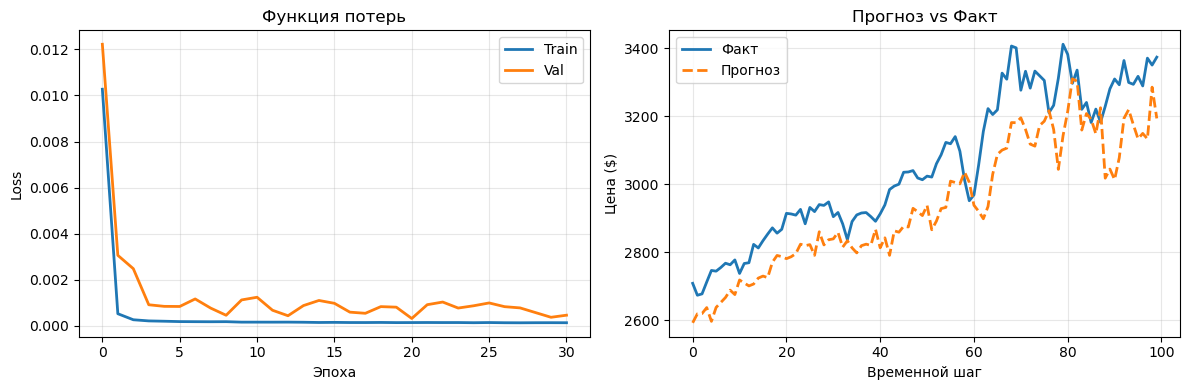

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train", linewidth=2)
plt.plot(history.history["val_loss"], label="Val", linewidth=2)
plt.title("Функция потерь")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(y_test_real[:100], label="Факт", linewidth=2)
plt.plot(y_pred_real[L : 100 + L], label="Прогноз", linewidth=2, linestyle="--")
plt.title("Прогноз vs Факт")
plt.xlabel("Временной шаг")
plt.ylabel("Цена ($)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

# Работа над ошибками
Построоить графики зависимостей *Loss* от M/L/D/NEURONS, проанализировать переобучение для данной задачи

## Сделаем функцию для подгоотвки данных к обучению модели

In [1]:
def create_dataset(data, M, D, L):
    """
    data — временной ряд
    M — ширина окна наблюдения
    D — глубина задержек
    L — горизонт прогноза
    """

    X = []
    y = []

    for i in range(len(data) - M - L - D):

        window = []

        for d in range(D):
            window.extend(data[i + d : i + d + M])

        X.append(window)
        y.append(data[i + M + D + L - 1])

    return np.array(X), np.array(y)

## Функция создания модели FFNN

In [13]:
from sklearn.model_selection import train_test_split


def build_model(input_size, neurons):

    model = tf.keras.Sequential(
        [
            tf.keras.layers.Flatten(input_shape=(input_size, 1)),
            tf.keras.layers.Dense(neurons, activation="relu"),
            tf.keras.layers.Dense(1),
        ]
    )

    return model


def train_model(data, M, D, L, neurons, epochs=30):

    X, y = create_dataset(data, M, D, L)

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    model = build_model(X.shape[1], neurons)

    model.compile(optimizer="adam", loss="mse", metrics=["mae"])

    history = model.fit(
        X_train, y_train, validation_data=(X_val, y_val), epochs=epochs, verbose=0
    )

    return model, history, X_train, X_val, y_train, y_val

## Задаём значения по умолчанию

In [7]:
M_fixed = 30
D_fixed = 10
L_fixed = 3
NEURONS_fixed = 256

## График зависимости LOSS от M

2026-04-01 17:19:29.431415: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 17:19:29.431467: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 17:19:30.253478: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_250', 28 bytes spill stores, 28 bytes spill loads

2026-04-01 17:19:30.697193: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : 

Text(0, 0.5, 'Validation Loss')

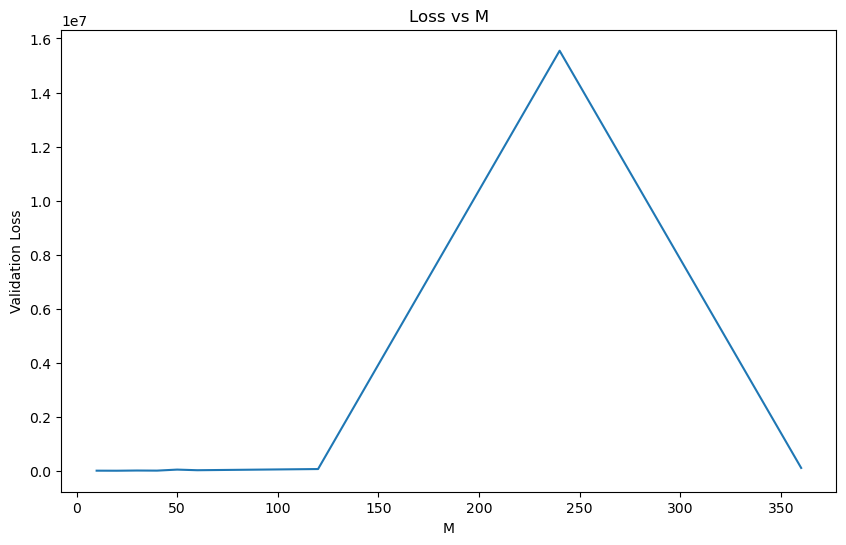

In [13]:
import matplotlib.pyplot as plt

M_values = [10, 20, 30, 40, 50, 60, 120, 240, 360]
loss_M = []

for M in M_values:

    model, history, X_train, X_val, y_train, y_val = train_model(
        data.to_numpy(), M, D_fixed, L_fixed, NEURONS_fixed
    )

    loss_M.append(history.history["val_loss"][-1])

plt.figure(figsize=(10, 6))
plt.plot(M_values, loss_M)
plt.title("Loss vs M")
plt.xlabel("M")
plt.ylabel("Validation Loss")

## график зависимости LOSS от D

2026-04-01 17:20:44.276496: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 17:20:44.276551: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 17:20:45.022343: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_250', 16 bytes spill stores, 16 bytes spill loads

2026-04-01 17:20:45.238018: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : 

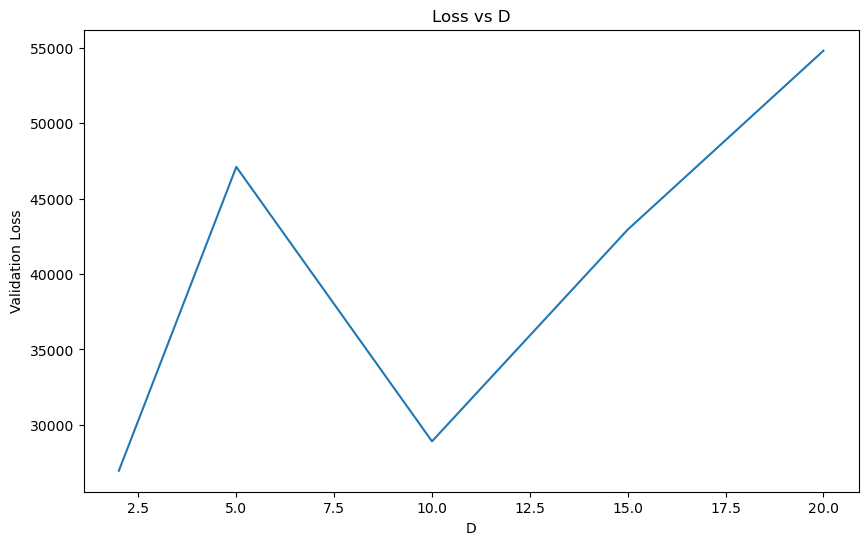

In [14]:
D_values = [2, 5, 10, 15, 20]
loss_D = []

for D in D_values:

    model, history, X_train, X_val, y_train, y_val = train_model(
        data.to_numpy(), M_fixed, D, L_fixed, NEURONS_fixed
    )

    loss_D.append(history.history["val_loss"][-1])

plt.figure(figsize=(10, 6))
plt.plot(D_values, loss_D)
plt.title("Loss vs D")
plt.xlabel("D")
plt.ylabel("Validation Loss")
plt.show()

## График щависимости LOSS от L

2026-04-01 17:21:23.807800: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 17:21:50.643405: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


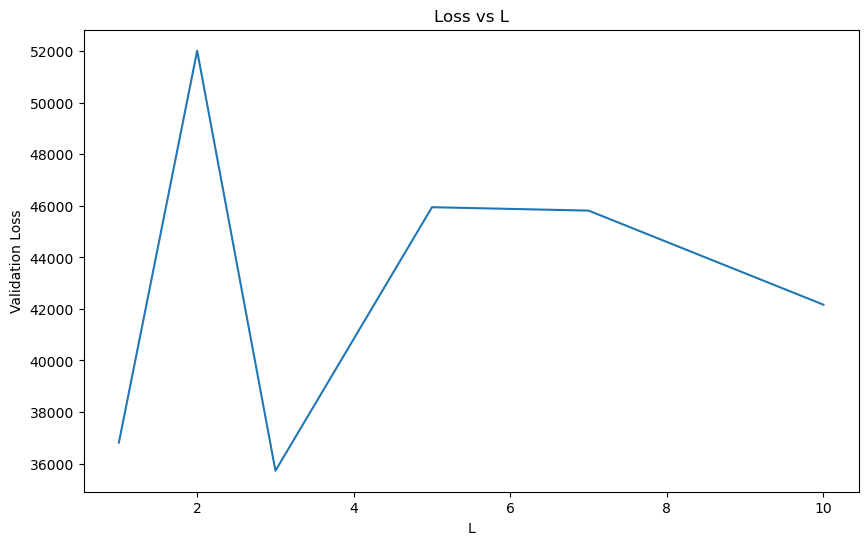

In [15]:
L_values = [1, 2, 3, 5, 7, 10]
loss_L = []

for L in L_values:

    hmodel, history, X_train, X_val, y_train, y_valistory = train_model(
        data.to_numpy(), M_fixed, D_fixed, L, NEURONS_fixed
    )

    loss_L.append(history.history["val_loss"][-1])

plt.figure(figsize=(10, 6))
plt.plot(L_values, loss_L)
plt.title("Loss vs L")
plt.xlabel("L")
plt.ylabel("Validation Loss")
plt.show()

## График зависимости LOSS от числа нейронов
Попытаемся найти переобчение (модель слишком крутая для наших данных)

2026-04-01 17:22:03.424315: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 17:22:05.737973: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 17:22:11.788677: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 17:22:11.788739: I external/l

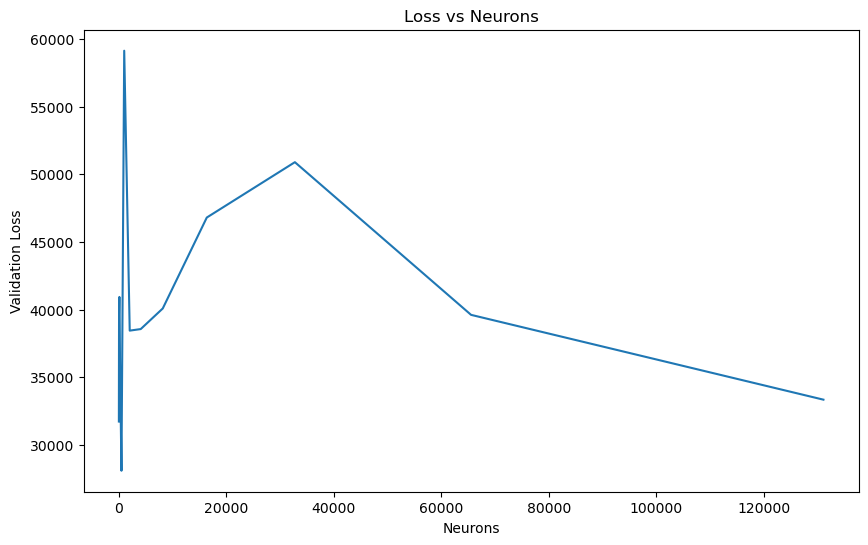

In [16]:
neurons_values = [2**x for x in range(5, 17 + 1)]
loss_neurons = []

for neurons in neurons_values:

    model, history, X_train, X_val, y_train, y_val = train_model(
        data.to_numpy(), M_fixed, D_fixed, L_fixed, neurons
    )

    loss_neurons.append(history.history["val_loss"][-1])

plt.figure(figsize=(10, 6))
plt.plot(neurons_values, loss_neurons)
plt.title("Loss vs Neurons")
plt.xlabel("Neurons")
plt.ylabel("Validation Loss")
plt.show()

## Графики переобучения

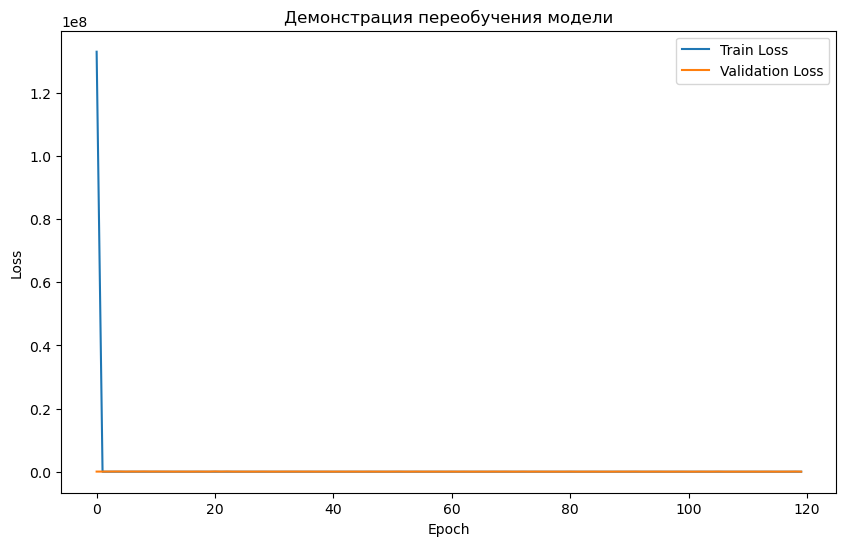

In [17]:
model, history, X_train, X_val, y_train, y_val = train_model(
    data.to_numpy(), M_fixed, D_fixed, L_fixed, neurons=65536, epochs=120
)

plt.figure(figsize=(10, 6))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Демонстрация переобучения модели")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

In [18]:
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


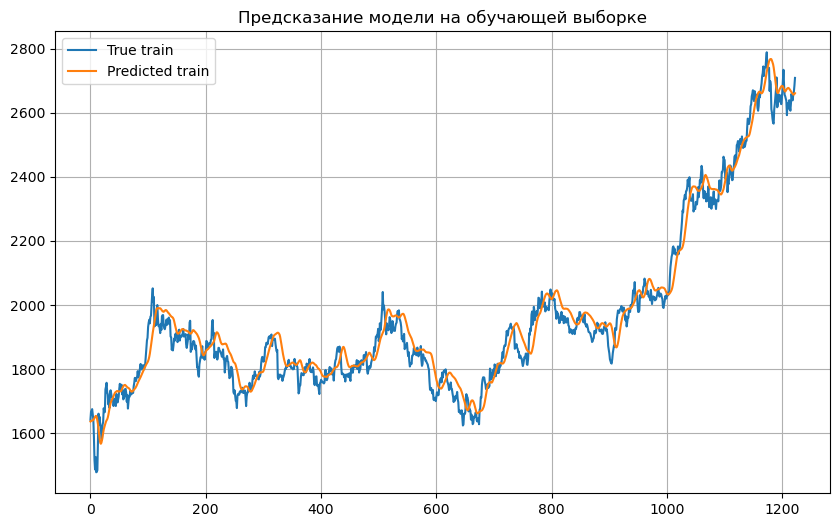

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(y_train, label="True train")
plt.plot(y_train_pred, label="Predicted train")

plt.title("Предсказание модели на обучающей выборке")
plt.legend()
plt.grid()

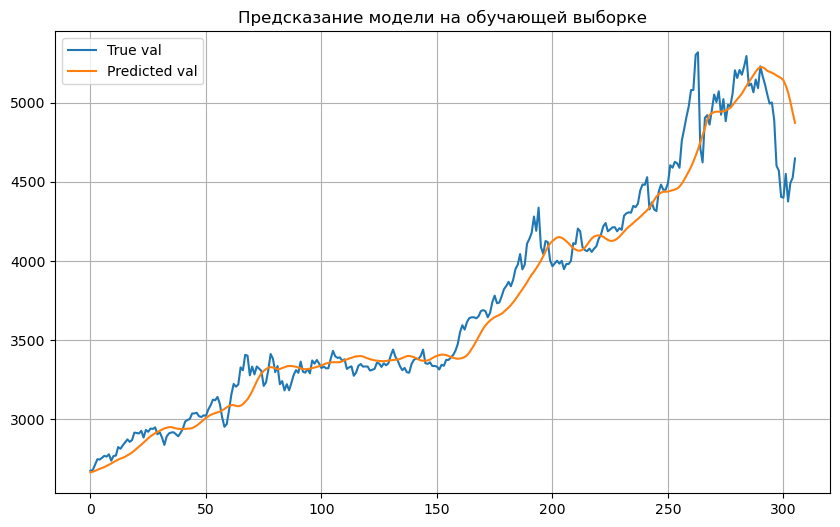

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(y_val, label="True val")
plt.plot(y_val_pred, label="Predicted val")

plt.title("Предсказание модели на обучающей выборке")
plt.legend()
plt.grid()

В ходе экспериментов по обучению нейронной сети прямого распространения с числом параметров порядка 120 000 явного эффекта переобучения обнаружено не было. Это объясняется рядом факторов.

Во-первых, объём обучающей выборки является достаточно большим по сравнению с числом настраиваемых параметров модели, что позволяет сети не запоминать обучающие данные, а выявлять устойчивые закономерности во временном ряде.

Во-вторых, используемый временной ряд обладает достаточно выраженной структурой и корреляцией между соседними значениями, что упрощает задачу прогнозирования и снижает вероятность запоминания случайных шумовых компонентов.

## Увеличим  кол-во обучающих данных и уменьшим кол-во валидирующих

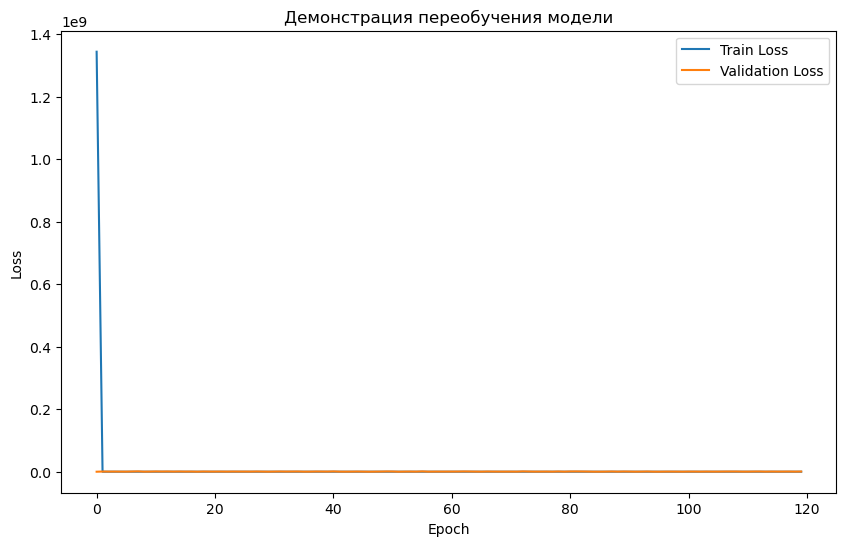

In [22]:
model, history, X_train, X_val, y_train, y_val = train_model(
    data.to_numpy(), M_fixed, D_fixed, L_fixed, neurons=65536*8, epochs=120
)

plt.figure(figsize=(10, 6))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Демонстрация переобучения модели")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

In [23]:
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


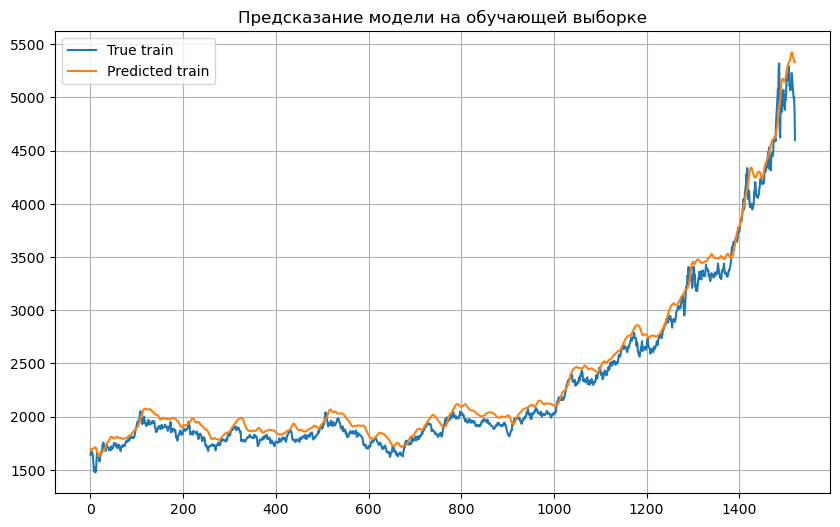

In [24]:
plt.figure(figsize=(10, 6))

plt.plot(y_train, label="True train")
plt.plot(y_train_pred, label="Predicted train")

plt.title("Предсказание модели на обучающей выборке")
plt.legend()
plt.grid()

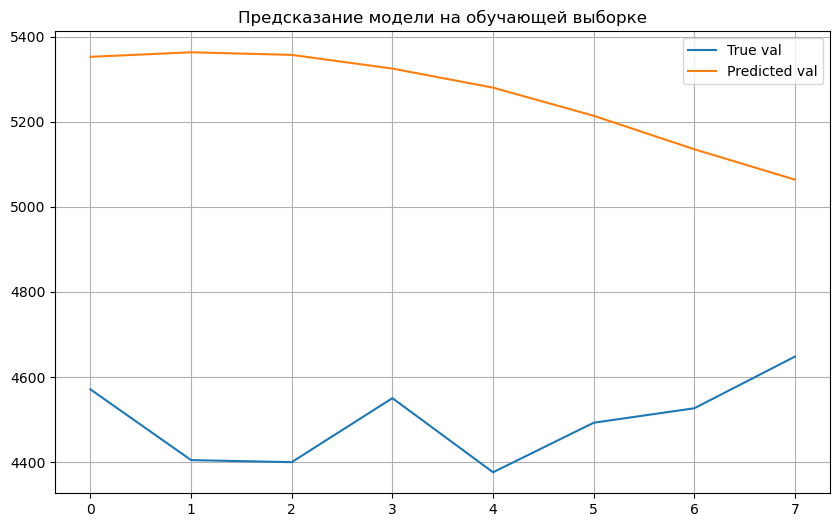

In [25]:
plt.figure(figsize=(10, 6))

plt.plot(y_val, label="True val")
plt.plot(y_val_pred, label="Predicted val")

plt.title("Предсказание модели на обучающей выборке")
plt.legend()
plt.grid()

## Попробуем уменьшить общее количесво данных

In [26]:
tickers = ["GC=F", "SI=F"]
data = yf.download(tickers, start="2026-01-01", progress=False)

gold = data["Close"]["GC=F"]
silver = data["Close"]["SI=F"]
data = pd.DataFrame({"gold": gold})
data.head()

,gold
Date,
2026-01-02,4314.399902
2026-01-05,4436.899902
2026-01-06,4482.200195
2026-01-07,4449.299805
2026-01-08,4449.700195


2026-04-01 17:38:09.947714: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-01 17:38:10.585189: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_250', 28 bytes spill stores, 28 bytes spill loads

2026-04-01 17:38:10.860511: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_250', 248 bytes spill stores, 248 bytes spill loads



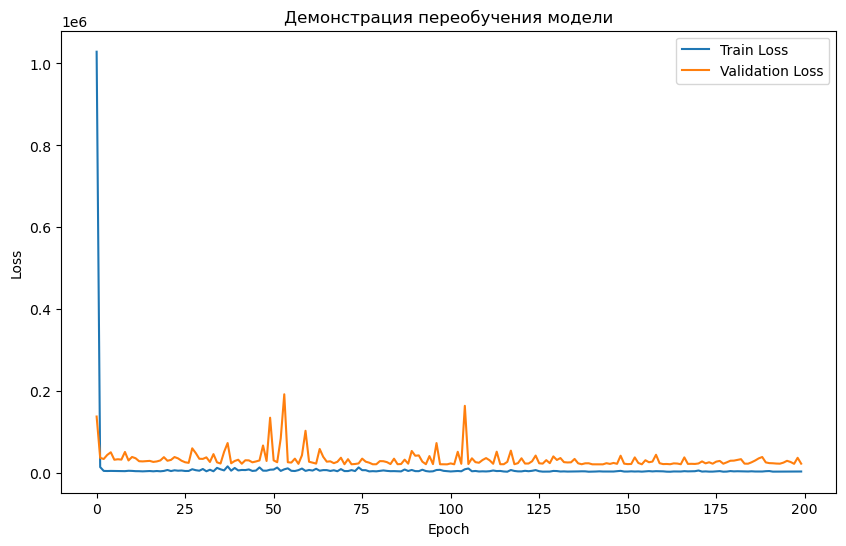

In [18]:
model, history, X_train, X_val, y_train, y_val = train_model(
    data.to_numpy(), 10, D_fixed, L_fixed, neurons=2048, epochs=200
)

plt.figure(figsize=(10, 6))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Демонстрация переобучения модели")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

In [19]:
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


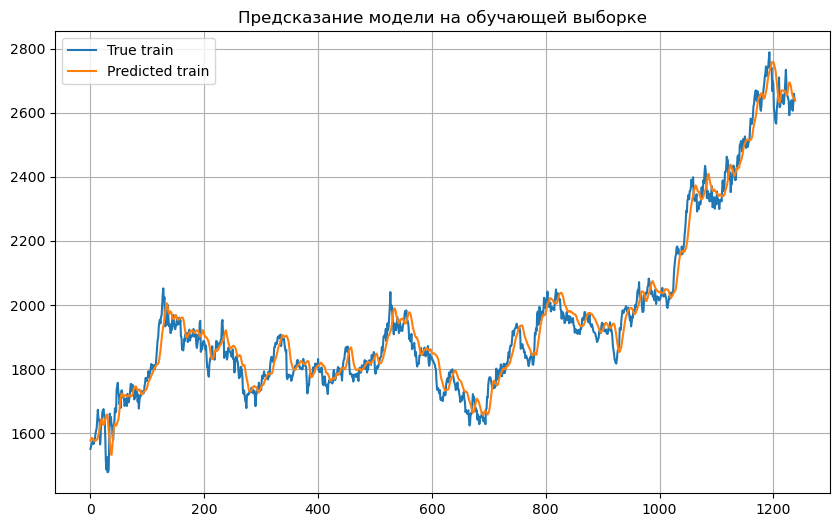

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(y_train, label="True train")
plt.plot(y_train_pred, label="Predicted train")

plt.title("Предсказание модели на обучающей выборке")
plt.legend()
plt.grid()

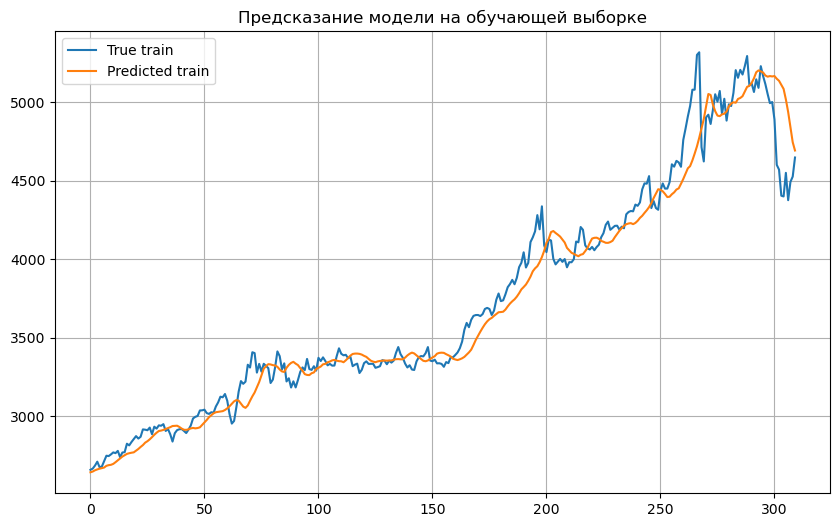

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(y_val, label="True train")
plt.plot(y_val_pred, label="Predicted train")

plt.title("Предсказание модели на обучающей выборке")
plt.legend()
plt.grid()